# ch311 — Dropout and Regularisation

## 1. The overfitting problem in deep networks

Deep networks have enough capacity to memorise training data entirely —
achieving zero training loss while failing on new data *(bias–variance tradeoff: ch276)*.
Regularisation techniques constrain the model to generalise.

---

## 2. L2 and L1 regularisation

Add a penalty to the loss:

$$\mathcal{L}_{\text{reg}} = \mathcal{L} + \lambda \|\theta\|_2^2 \quad (\text{L2, weight decay})$$
$$\mathcal{L}_{\text{reg}} = \mathcal{L} + \lambda \|\theta\|_1 \quad (\text{L1, sparsity})$$

L2 (weight decay) shrinks all weights uniformly. L1 pushes small weights to exactly zero,
producing sparse solutions. For neural networks, L2 is standard — it corresponds to a
Gaussian prior on weights *(Bayesian view: ch292)*.

The L2 gradient update becomes: $\theta \leftarrow \theta(1 - \eta\lambda) - \eta g$

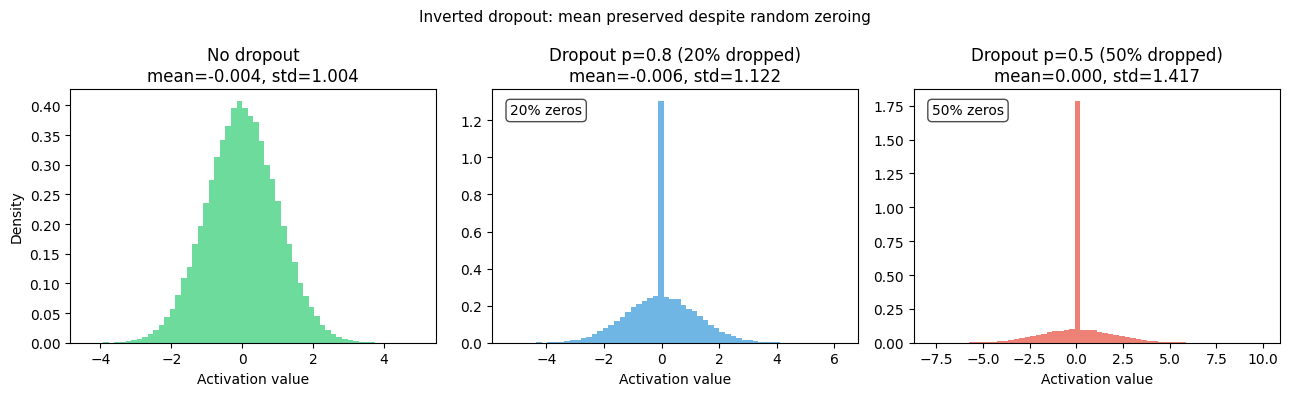

In [1]:
import numpy as np
import matplotlib.pyplot as plt


class Dropout:
    """Inverted dropout: scales at training time so inference requires no change."""

    def __init__(self, p: float):
        """p = probability of KEEPING a unit (keep_prob). Drop prob = 1-p."""
        assert 0 < p <= 1, "p must be in (0, 1]"
        self.p = p
        self.mask = None

    def forward(self, A: np.ndarray, training: bool = True) -> np.ndarray:
        if not training or self.p == 1.0:
            return A
        # Inverted dropout: scale by 1/p so expected value is preserved
        self.mask = (np.random.rand(*A.shape) < self.p) / self.p
        return A * self.mask

    def backward(self, dA: np.ndarray) -> np.ndarray:
        return dA * self.mask


# Demonstrate: effect of dropout on activation distribution and co-adaptation
rng = np.random.default_rng(42)
n_neurons, batch = 200, 500
A = rng.normal(0, 1, (n_neurons, batch))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
p_values = [1.0, 0.8, 0.5]
titles = ['No dropout', 'Dropout p=0.8 (20% dropped)', 'Dropout p=0.5 (50% dropped)']
colors = ['#2ecc71', '#3498db', '#e74c3c']

for ax, p, title, color in zip(axes, p_values, titles, colors):
    dp = Dropout(p)
    A_out = dp.forward(A, training=True)
    # Show neuron activation rates
    active_fraction = (A_out != 0).mean(axis=1)
    ax.hist(A_out.ravel(), bins=60, color=color, alpha=0.7, density=True, label='Activations')
    ax.set_title(f'{title}\nmean={A_out.mean():.3f}, std={A_out.std():.3f}')
    ax.set_xlabel('Activation value')
    if p < 1.0:
        frac = (A_out.ravel() == 0).mean()
        ax.text(0.05, 0.9, f'{frac:.0%} zeros', transform=ax.transAxes, fontsize=10,
                color='black', bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

axes[0].set_ylabel('Density')
plt.suptitle('Inverted dropout: mean preserved despite random zeroing', fontsize=11)
plt.tight_layout()
plt.savefig('ch311_dropout.png', dpi=120)
plt.show()

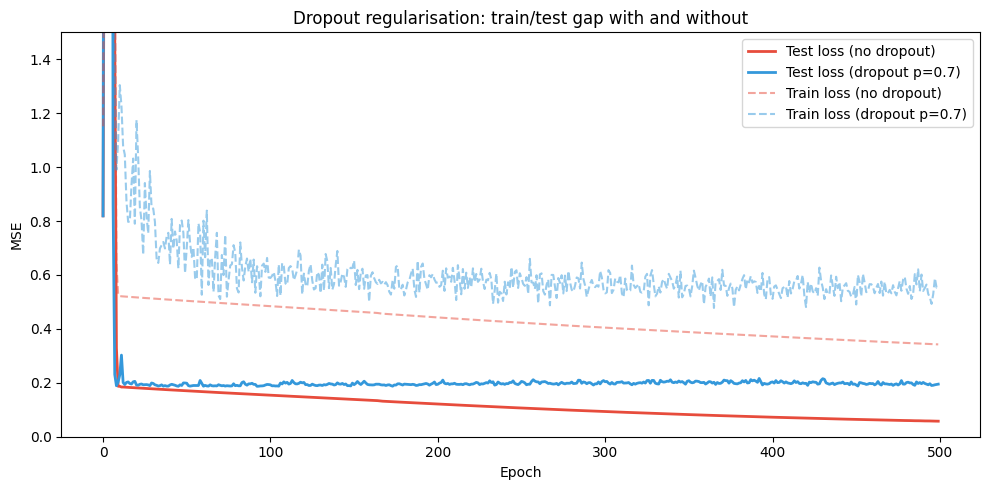

Final test MSE — no dropout: 0.0576 | dropout: 0.1950


In [2]:
# Train a small network with/without dropout on noisy data
# and compare generalisation
import numpy as np

rng = np.random.default_rng(1)
n_train, n_test = 100, 500

# Noisy 1D regression: y = sin(x) + noise
def make_data(n, noise=0.5):
    x = rng.uniform(-np.pi, np.pi, n)
    y = np.sin(x) + rng.normal(0, noise, n)
    return x[:, None], y[:, None]

X_tr, y_tr = make_data(n_train)
X_te, y_te = make_data(n_test, noise=0.0)

def sigmoid(z): return 1/(1+np.exp(-z))
def sigmoid_grad(z): s=sigmoid(z); return s*(1-s)
def relu(z): return np.maximum(0,z)
def relu_grad(z): return (z>0).astype(float)

def train_net(use_dropout=False, p_keep=0.7, lr=0.01, n_epochs=500, l2=0.001):
    rng2 = np.random.default_rng(42)
    W1 = rng2.normal(0, np.sqrt(2/1), (64, 1))
    b1 = np.zeros((64,1))
    W2 = rng2.normal(0, np.sqrt(2/64), (64, 64))
    b2 = np.zeros((64,1))
    W3 = rng2.normal(0, np.sqrt(2/64), (1, 64))
    b3 = np.zeros((1,1))

    train_losses, test_losses = [], []
    dp1 = Dropout(p_keep)
    dp2 = Dropout(p_keep)

    for epoch in range(n_epochs):
        X = X_tr.T; y = y_tr.T
        Z1 = W1@X + b1; A1 = relu(Z1)
        if use_dropout: A1 = dp1.forward(A1, training=True)
        Z2 = W2@A1 + b2; A2 = relu(Z2)
        if use_dropout: A2 = dp2.forward(A2, training=True)
        Z3 = W3@A2 + b3; yhat = Z3

        loss_train = float(np.mean((yhat - y)**2))
        train_losses.append(loss_train)

        # Test (no dropout)
        A1t = relu(W1@X_te.T + b1)
        A2t = relu(W2@A1t + b2)
        yhat_t = W3@A2t + b3
        test_losses.append(float(np.mean((yhat_t - y_te.T)**2)))

        # Backward
        B = X.shape[1]
        dZ3 = (yhat - y) * 2 / B
        dW3 = dZ3 @ A2.T + l2*W3
        db3 = dZ3.sum(axis=1, keepdims=True)
        dA2 = W3.T @ dZ3
        if use_dropout: dA2 = dp2.backward(dA2)
        dZ2 = dA2 * relu_grad(Z2)
        dW2 = dZ2 @ A1.T + l2*W2
        db2 = dZ2.sum(axis=1, keepdims=True)
        dA1 = W2.T @ dZ2
        if use_dropout: dA1 = dp1.backward(dA1)
        dZ1 = dA1 * relu_grad(Z1)
        dW1 = dZ1 @ X.T + l2*W1
        db1 = dZ1.sum(axis=1, keepdims=True)
        for W,dW in [(W1,dW1),(W2,dW2),(W3,dW3)]:
            W -= lr*dW
        for b,db in [(b1,db1),(b2,db2),(b3,db3)]:
            b -= lr*db

    return train_losses, test_losses

tr_no, te_no = train_net(use_dropout=False)
tr_do, te_do = train_net(use_dropout=True, p_keep=0.7)

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(te_no, label='Test loss (no dropout)', color='#e74c3c', lw=2)
ax.plot(te_do, label='Test loss (dropout p=0.7)', color='#3498db', lw=2)
ax.plot(tr_no, '--', label='Train loss (no dropout)', color='#e74c3c', alpha=0.5)
ax.plot(tr_do, '--', label='Train loss (dropout p=0.7)', color='#3498db', alpha=0.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE')
ax.set_title('Dropout regularisation: train/test gap with and without')
ax.legend()
ax.set_ylim(0, 1.5)
plt.tight_layout()
plt.savefig('ch311_dropout_effect.png', dpi=120)
plt.show()
print(f"Final test MSE — no dropout: {te_no[-1]:.4f} | dropout: {te_do[-1]:.4f}")

## 3. Other regularisation techniques

| Technique | Mechanism | When to use |
|-----------|-----------|-------------|
| L2 (weight decay) | Penalise large weights | Always; cheap to add |
| L1 | Penalise non-zero weights | When sparse features desirable |
| Dropout | Random zeroing during training | Wide MLPs, Transformers |
| DropConnect | Drop weights not activations | Rare; slightly stronger than dropout |
| Data augmentation | Expand training set artificially | Computer vision (ch335) |
| Early stopping | Halt when val loss stops decreasing | Always a good baseline |
| Batch norm | Slight noise from batch statistics | CNNs (not a primary regulariser) |

---

## 4. Ensemble interpretation of dropout

At test time, dropout approximates an ensemble average over $2^d$ thinned networks
(where $d$ is the number of dropout units). This is why it reduces variance.

---

## 5. Summary

- L2 regularisation = Gaussian prior on weights; L1 = Laplace prior → sparsity.
- Dropout randomly zeroes neurons during training; inverted dropout preserves expected activation.
- Regularisation reduces the train-test gap by preventing co-adaptation of neurons.
- Use weight decay always; add dropout for wide networks and Transformers.

---

## 6. Forward and backward references

**Used here:** overfitting and bias–variance *(ch276)*, gradient update *(ch307)*,
Bayesian prior view *(ch292)*.

**This will reappear in ch322 — Transformers**, where dropout is applied after every
attention and feed-forward sublayer, and in ch334 — Project: Neural Net from Scratch.